# 01 — Exploratory data analysis

Gas Wait currently has three weekly EIA series. This notebook inspects them **before any model is trained**.

Questions:
1. What is the coverage and native frequency of each series?
2. Where is data missing?
3. Do the series actually line up in time?
4. How do 1/2/4/8-week changes behave?
5. What correlations exist in levels vs changes?
6. Do WTI and inventories **lead** retail gasoline, and by how many weeks?
7. Is there seasonality?
8. Which extreme moves match known historical events?
9. Is there enough predictive information to justify a model?
10. Which target should we use for WAIT / FILL UP / NO CLEAR SIGNAL?

No synthetic data. No additional downloads. Features never use future retail prices; future shifts appear only as **candidate labels**.



In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
from matplotlib import image as mpimg

NOTEBOOK_DIR = Path.cwd()
if (NOTEBOOK_DIR / "_run_eda.py").exists():
    pass
elif (NOTEBOOK_DIR / "notebooks" / "_run_eda.py").exists():
    NOTEBOOK_DIR = NOTEBOOK_DIR / "notebooks"
elif (NOTEBOOK_DIR / "gas_wait" / "notebooks" / "_run_eda.py").exists():
    NOTEBOOK_DIR = NOTEBOOK_DIR / "gas_wait" / "notebooks"

sys.path.insert(0, str(NOTEBOOK_DIR.resolve()))

from _run_eda import FIGURES, PROCESSED, run

pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 140)
pd.set_option("display.float_format", lambda x: f"{x:0.4f}")

findings = run()
print("Tables written to", PROCESSED)
print("Figures written to", FIGURES)


def show_figure(name: str) -> None:
    path = FIGURES / name
    image = mpimg.imread(path)
    fig, ax = plt.subplots(figsize=(11, 4.8))
    ax.imshow(image)
    ax.axis("off")
    fig.suptitle(name.replace("_", " ").replace(".png", ""), y=0.02, fontsize=9)
    plt.show()
    plt.close(fig)



EDA complete
{
  "aligned_rows": 1873,
  "typical_wti_lead_days": 3.0,
  "level_corr_retail_wti": 0.9607191558123458,
  "chg1_corr_retail_wti": 0.576399915184725,
  "chg1_corr_retail_stocks": -0.19713787305865782,
  "retail_ac1": 0.5526785838205721,
  "share_wait_1w_saves": 0.5189535504538174,
  "mean_abs_1w_retail_change": 0.03293696581196582
}
                                        target  mean_abs_change_usd  share_price_lower  corr_wti_chg_1w  corr_retail_momentum  sign_acc_wti_chg  majority_baseline
       TARGET A: retail change 1 week(s) ahead               0.0329             0.5190           0.3817                0.5527            0.6243             0.5190
       TARGET B: retail change 2 week(s) ahead               0.0592             0.5029           0.3249                0.5062            0.6230             0.5029
       TARGET C: retail change 3 week(s) ahead               0.0822             0.4939           0.3045                0.4720            0.6073             0.5061


## 1. Date ranges and observation frequency

All three series are natively **weekly** with a 7-day step and no irregular gaps. They do **not** share a weekday, which matters for alignment in section 3.

Retail gasoline is the shortest series (starts 1990-08-20). WTI starts in 1986. Inventories start 1990-01-05.



In [2]:
coverage = pd.read_csv(PROCESSED / "eda_coverage_summary.csv")
coverage



                              dataset  observations  non_null_values  missing_values       start         end frequency_claimed        weekday  median_gap_days  max_gap_days  irregular_gaps       units_in_file                                                         series_description              geographic_area         min      median         max
0  U.S. regular gasoline retail price          1879             1873               6  1990-08-20  2026-08-17            weekly  Monday (1879)           7.0000        7.0000               0  dollars per gallon  U.S. Regular All Formulations Retail Gasoline Prices (Dollars per Gallon)                United States      0.9070      2.2890      5.0060
1            WTI crude oil spot price          2120             2120               0  1986-01-03  2026-08-14            weekly  Friday (2120)           7.0000        7.0000               0  dollars per barrel                        Cushing, OK WTI Spot Price FOB (Dollars per Barrel)  United States (Cu

## 2. Missing observations

Calendar weeks are complete for every series. The only null **values** are six consecutive retail prices from 1990-12-10 through 1991-01-14, matching EIA's documented pause in weekly retail gasoline collection. Those rows are dropped from the modeling panel. WTI and inventories have no missing values.



In [3]:
missing = pd.read_csv(PROCESSED / "eda_missing_observations.csv")
missing



  observation_date                             dataset                                                            issue
0       1990-12-10  U.S. regular gasoline retail price  Null retail price; EIA paused weekly retail gasoline collection
1       1990-12-17  U.S. regular gasoline retail price  Null retail price; EIA paused weekly retail gasoline collection
2       1990-12-24  U.S. regular gasoline retail price  Null retail price; EIA paused weekly retail gasoline collection
3       1990-12-31  U.S. regular gasoline retail price  Null retail price; EIA paused weekly retail gasoline collection
4       1991-01-07  U.S. regular gasoline retail price  Null retail price; EIA paused weekly retail gasoline collection
5       1991-01-14  U.S. regular gasoline retail price  Null retail price; EIA paused weekly retail gasoline collection


## 3. Temporal alignment

This is the most important data-cleaning result.

- Retail gasoline observations are **Mondays**.
- WTI weekly and gasoline stocks are **Fridays**.
- Exact calendar-date overlap between retail and the other two series: **0**.

Joining on `observation_date` equality would produce an empty panel. A nearest-date join would leak the **next** Friday (4 days after Monday) into the retail row.

The valid join is `merge_asof(..., direction="backward")` with a 6-day tolerance: each Monday retail price is paired with the Friday WTI/stocks observation **on or before** that Monday. Empirically that Friday is always **3 days earlier**.

That means even "lag 0" WTI is already a slightly leading cost signal, not a same-morning print. Publication lag (when EIA releases the number) is a further limitation and is not in this extract.



In [4]:
alignment = pd.read_csv(PROCESSED / "eda_alignment_summary.csv")
alignment



                                            item                                                                                                                                         value
0                                 retail weekday                                                                                                  Monday (EIA Gasoline and Diesel Fuel Update)
1                                    wti weekday                                                                                                      Friday (weekly WTI series ending Friday)
2                                 stocks weekday                                                                                           Friday (Weekly Petroleum Status Report week ending)
3     exact calendar-date overlap, retail vs WTI                                                                                                                                             0
4  exact calendar-date overlap, retail vs sto

## 4. Multi-horizon changes

Changes are computed on the aligned Monday panel, using each series' **native weekly** values. We do not upsample to daily.

Retail 1-week moves are small: mean change ≈ $0.002, mean absolute change ≈ **$0.033/gal**. About 52% of weeks the price falls. WTI is much noisier week to week. Inventory changes are small relative to the ~217 million barrel stock level.

Longer horizons inflate both the signal and the shared-trend component. That is why 8-week WTI–retail change correlations look stronger without being more useful for a 1-week decision.



In [5]:
changes = pd.read_csv(PROCESSED / "eda_change_stats.csv")
changes



             series  horizon_weeks     n  mean_change  median_change  std_change  mean_pct  median_pct  std_pct  pct_negative  pct_positive
0   retail gasoline              1  1872       0.0015        -0.0020      0.0525    0.0008     -0.0009   0.0198        0.5190        0.4640
1   retail gasoline              2  1871       0.0030        -0.0010      0.0925    0.0019     -0.0005   0.0349        0.5029        0.4864
2   retail gasoline              4  1869       0.0060         0.0010      0.1591    0.0044      0.0008   0.0601        0.4875        0.5029
3   retail gasoline              8  1865       0.0116         0.0050      0.2587    0.0097      0.0028   0.0965        0.4805        0.5115
4               WTI              1  1872       0.0303         0.1100      2.5227    0.0033      0.0028   0.0994        0.4650        0.5312
5               WTI              2  1871       0.0565         0.1500      3.7971    0.0063      0.0045   0.1572        0.4714        0.5259
6               WTI 

## Visualizations — levels, comparison, and rolling changes



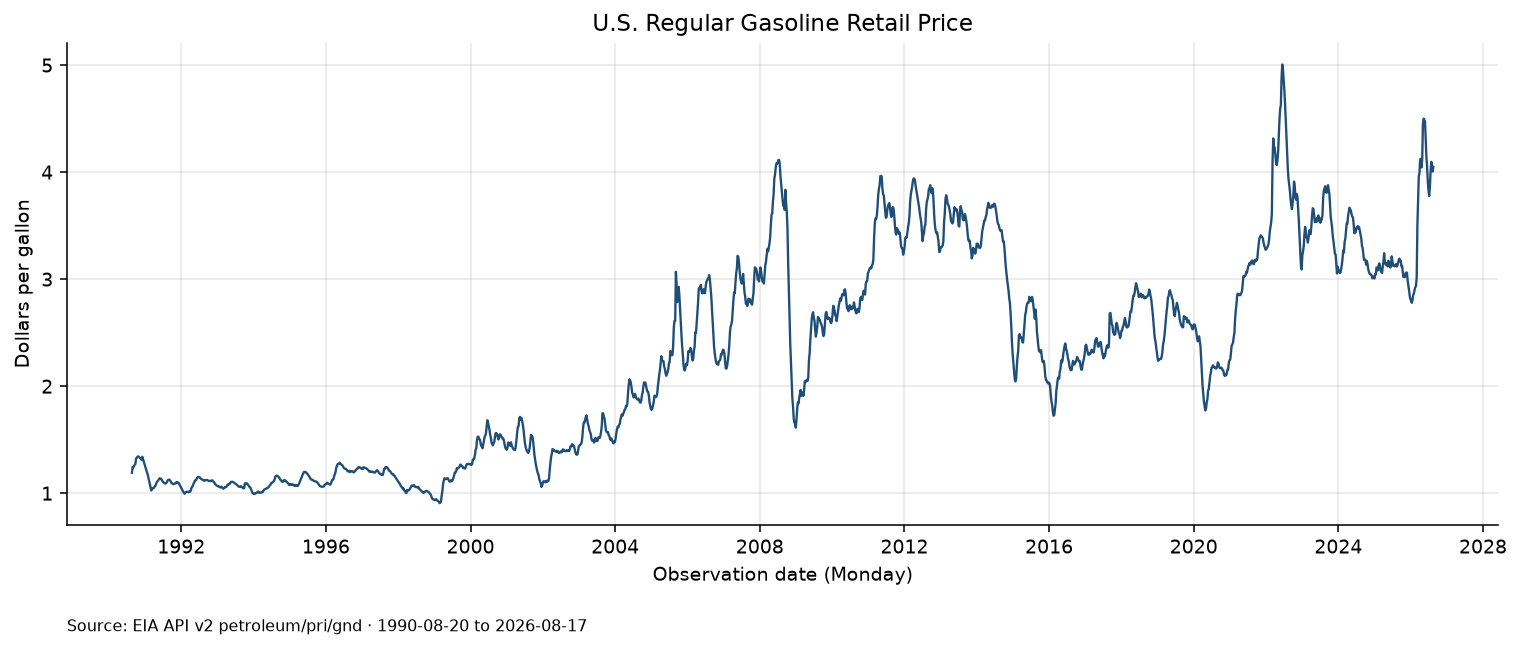

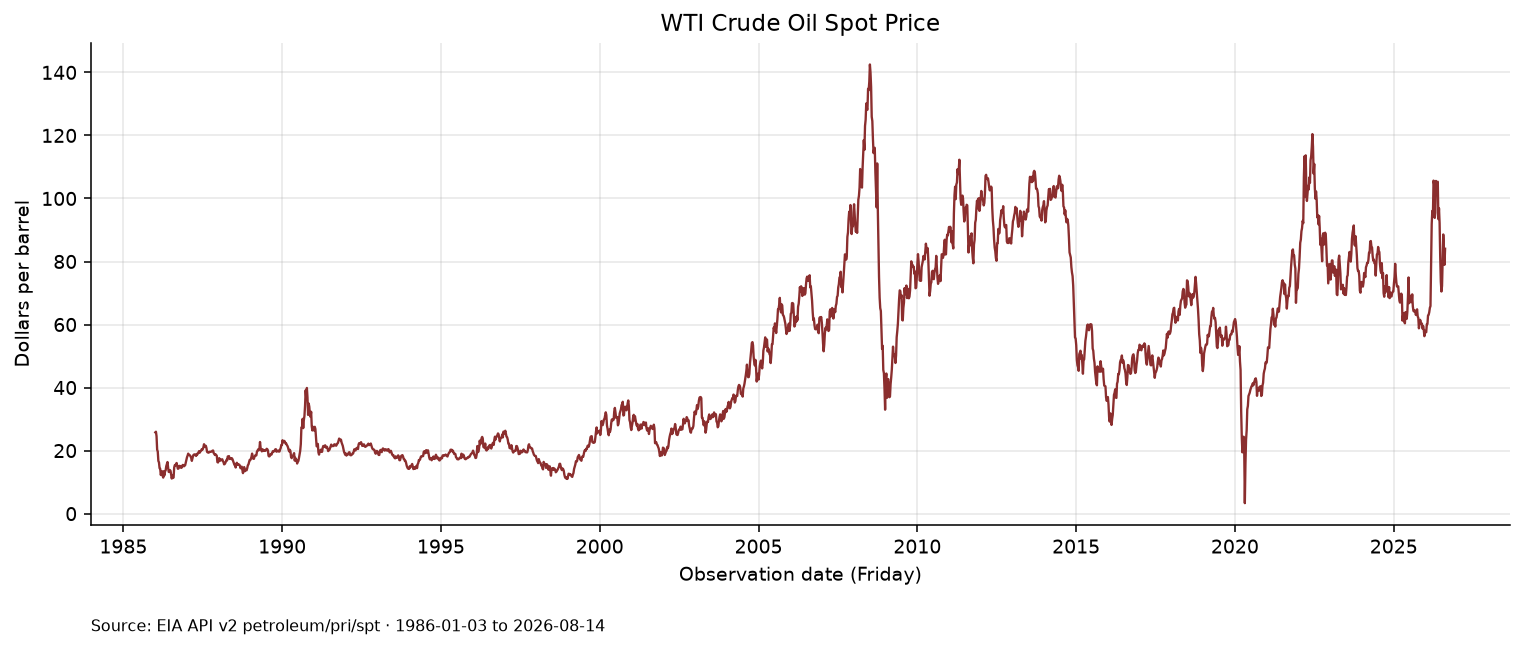

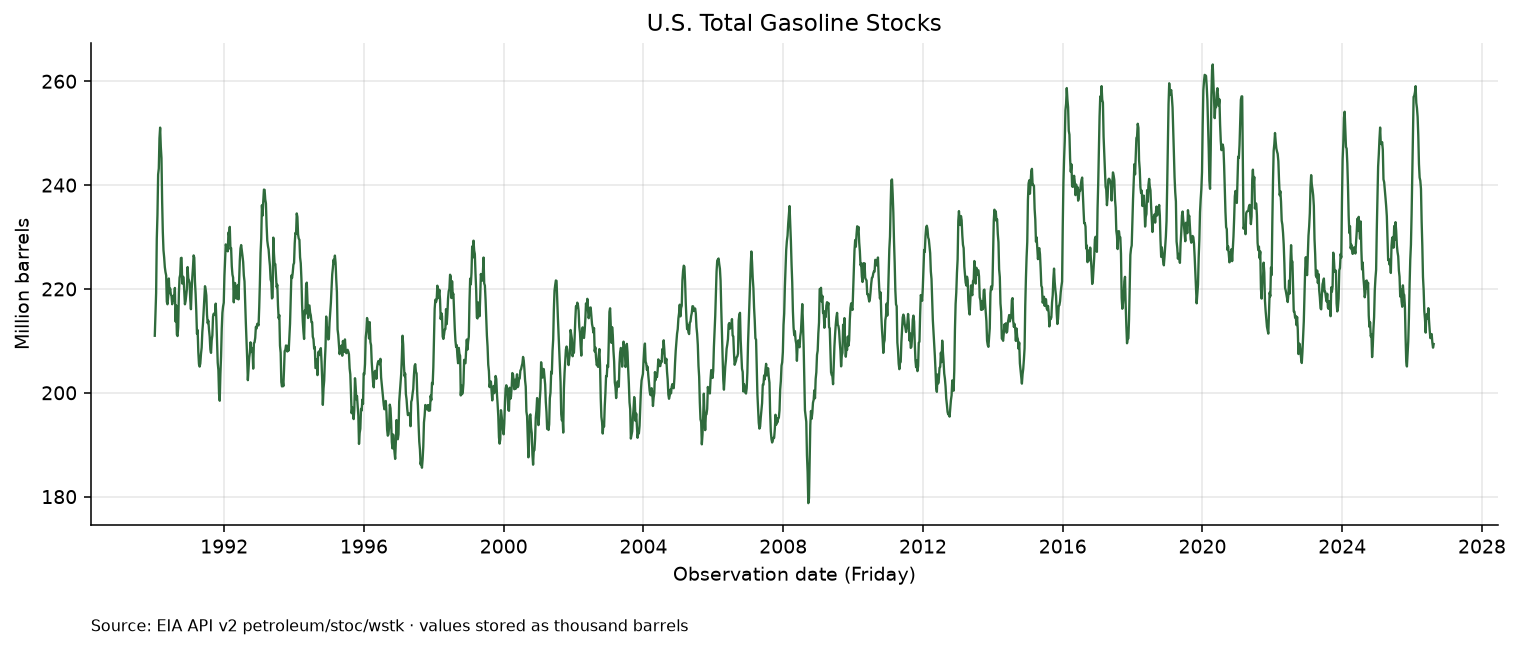

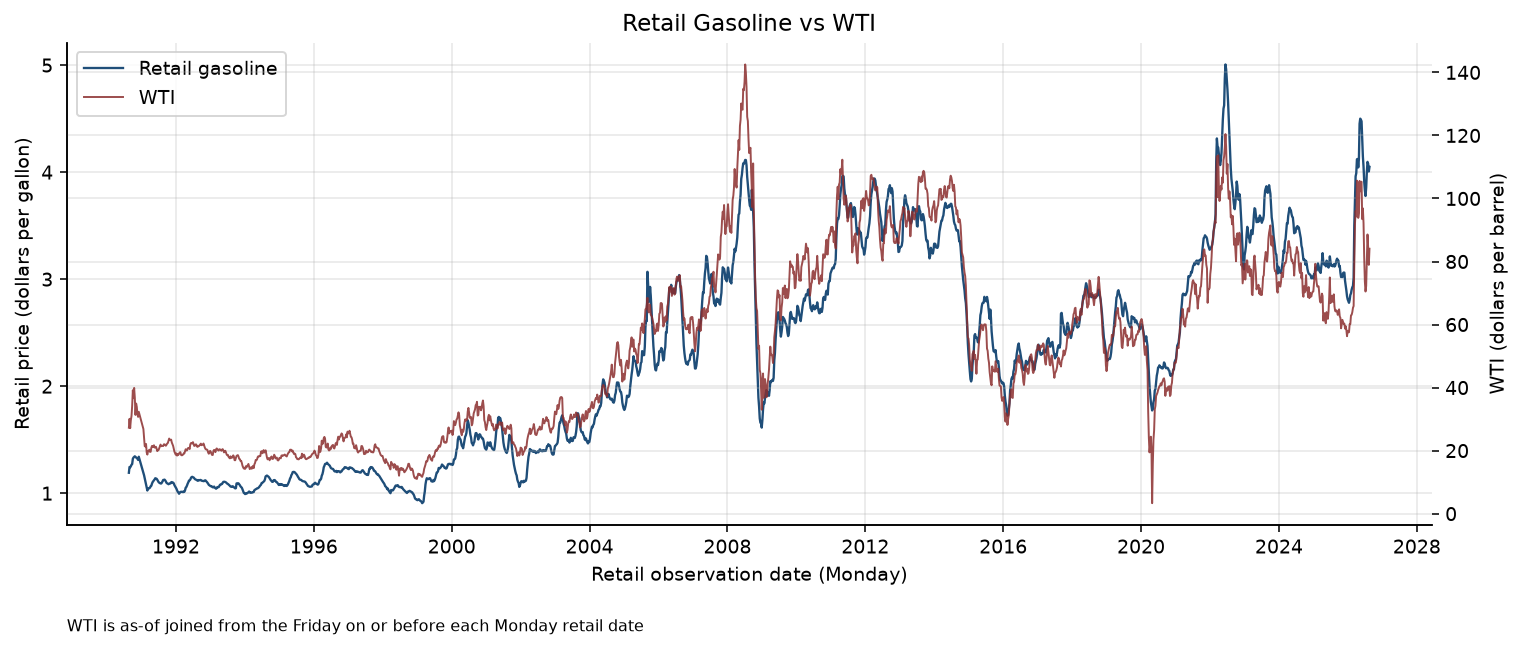

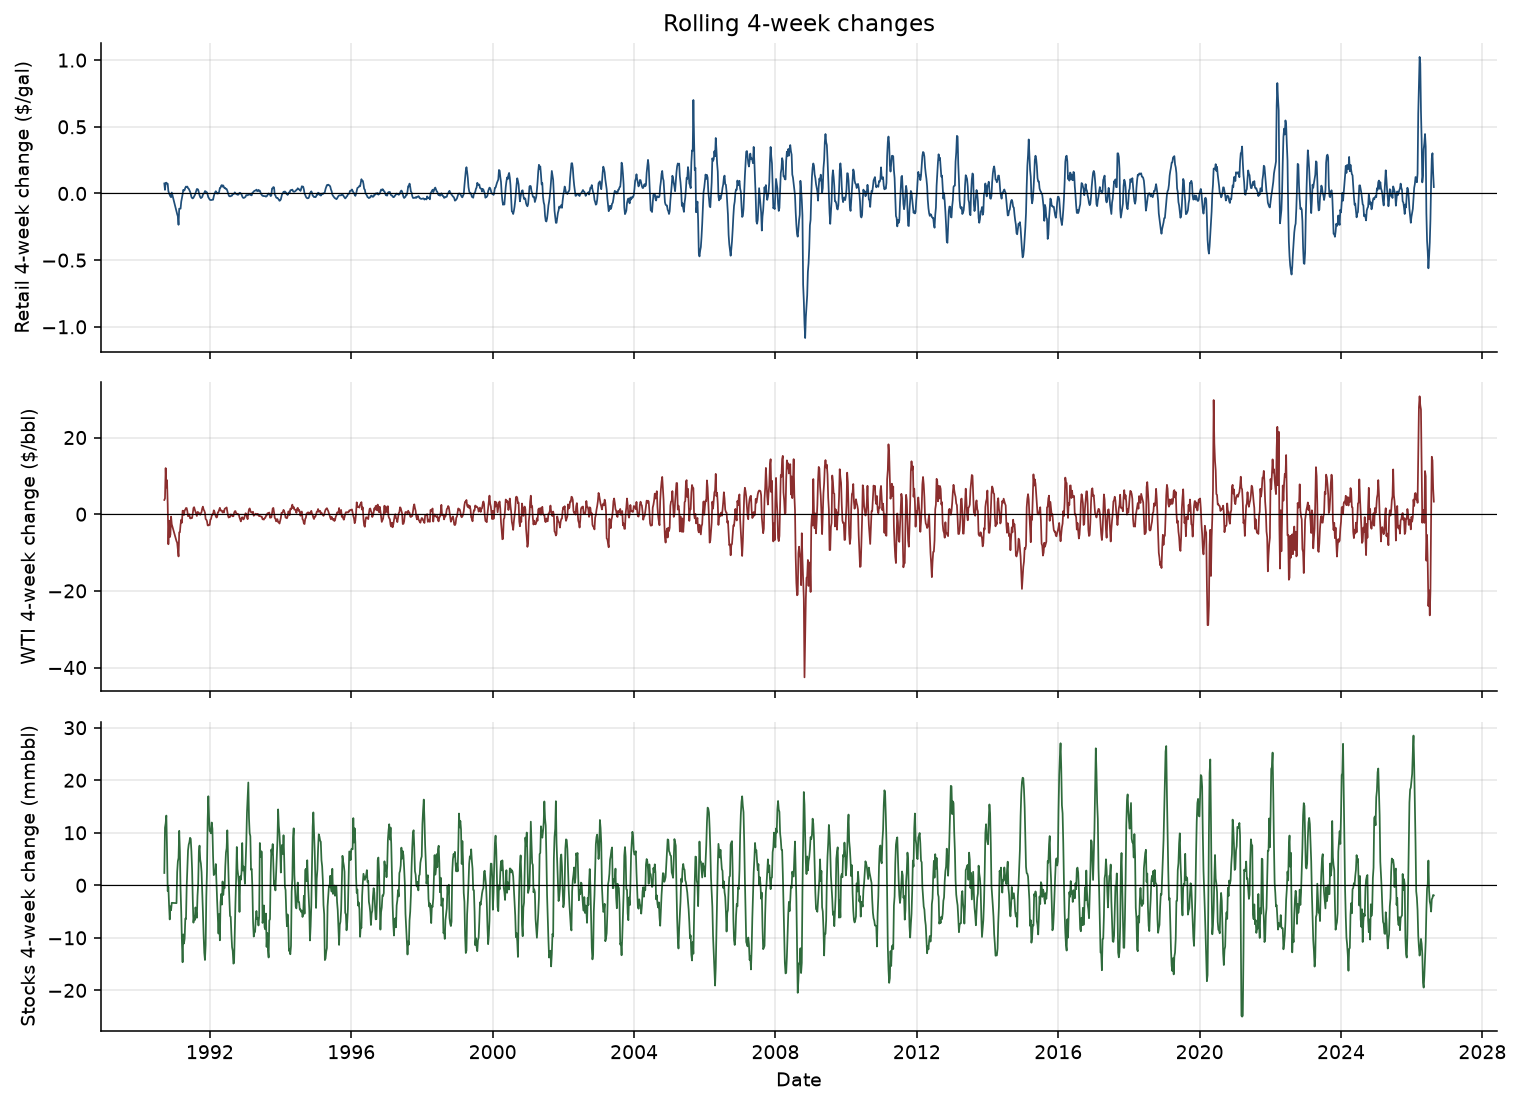

In [6]:
show_figure("retail_price_over_time.png")
show_figure("wti_price_over_time.png")
show_figure("gasoline_stocks_over_time.png")
show_figure("retail_vs_wti_levels.png")
show_figure("rolling_4w_changes.png")



## 5. Correlations

**Levels:** retail gasoline and WTI are extremely correlated (Pearson **0.96**). That is a shared long-run trend, not a 1-week trading signal. Modeling price *levels* would overstate predictability.

**Changes:** 1-week dollar changes in retail vs WTI have Pearson **0.58**. Percent-change Pearson is weaker (**0.25**) than Spearman (**0.53**) because WTI percent moves explode when the oil price is near zero (2020). Dollar changes, or robust/Spearman relationships, are safer than raw WTI percent changes.

**Inventories:** 1-week inventory changes vs retail changes are only **−0.20**. The sign is economically right (builds ↔ lower prices) but the relationship is much weaker than crude. Seasonal inventory deviation vs 4-week retail changes is essentially zero — seasonality in stocks does not, by itself, explain retail moves.

**Momentum:** retail 1-week changes have lag-1 autocorrelation **0.55**. Pump prices are sticky week to week.



In [7]:
corr = pd.read_csv(PROCESSED / "eda_correlations.csv")
corr



                                            relationship              x                    y     n  pearson  pearson_p  spearman  spearman_p
0                              retail level vs WTI level   retail_price            wti_price  1873   0.9607     0.0000    0.9678      0.0000
1                        retail level vs inventory level   retail_price      gasoline_stocks  1873   0.2718     0.0000    0.2628      0.0000
2              1-week retail change vs 1-week WTI change  retail_chg_1w           wti_chg_1w  1872   0.5764     0.0000    0.5381      0.0000
3                    1-week retail pct vs 1-week WTI pct  retail_pct_1w           wti_pct_1w  1872   0.2509     0.0000    0.5311      0.0000
4              2-week retail change vs 2-week WTI change  retail_chg_2w           wti_chg_2w  1871   0.6527     0.0000    0.5984      0.0000
5                    2-week retail pct vs 2-week WTI pct  retail_pct_2w           wti_pct_2w  1871   0.2833     0.0000    0.5866      0.0000
6            

## 6. Lagged relationships (measured, not assumed)

Definition: correlation of `predictor.shift(k)` with the 1-week retail change ending at Monday `t`. Positive `k` means the predictor **precedes** the retail change. Lag 0 uses the Friday print from 3 days earlier — already available before we try to forecast the *next* Monday.

### WTI → retail

| lag (weeks) | Pearson vs this week's retail change |
| ---: | ---: |
| 0 | 0.58 |
| 1 | 0.38 |
| 2 | 0.19 |
| 3 | 0.17 |
| 4 | 0.12 |
| 6 | 0.09 |
| 8 | 0.05 |

The lead is **short**. Most of the WTI association is contemporaneous-week (Friday into Monday). There is still useful **1-week-ahead** information (0.38). By 4–8 weeks the correlation has mostly decayed.

Forecast view, using this week's WTI change to predict *future* retail change:

- 1 week ahead: 0.38
- 2 weeks ahead: 0.32
- 3 weeks ahead: 0.30

### Inventories → retail

Inventory changes peak at lag 1 (**−0.21**), then fade and **flip sign** at lags 6–8. That sign flip is a seasonal/mean-reversion artifact, not a stable 2-month lead. Inventories are a secondary feature, not the main engine.

### Momentum

Last week's retail change remains the single strongest 1-week-ahead correlate (**0.55**). That is valid as a feature (it uses only prices already observed) but it is persistence, not a causal cost shock.



In [8]:
lags = pd.read_csv(PROCESSED / "eda_lagged_correlations.csv")
same_week = lags[lags["target"] == "retail 1-week change at t"]
same_week.pivot_table(index="lag_weeks", columns="predictor", values="pearson")



predictor  WTI 1-week change  WTI 1-week pct change  inventory 1-week change  inventory 1-week pct change  inventory seasonal deviation  retail 1-week change (momentum)
lag_weeks                                                                                                                                                               
0                     0.5764                 0.2282                  -0.1971                      -0.1987                        0.0040                           1.0000
1                     0.3817                 0.1713                  -0.2115                      -0.2125                        0.0332                           0.5527
2                     0.1894                 0.0851                  -0.1660                      -0.1676                        0.0669                           0.3384
3                     0.1664                 0.0961                  -0.0894                      -0.0915                        0.0944                    

In [9]:
forecast = lags[(lags["lag_weeks"] == 0) & lags["target"].str.contains("ahead")]
forecast.pivot_table(index="target", columns="predictor", values="pearson")



predictor                      WTI 1-week change  WTI 1-week pct change  inventory 1-week change  inventory 1-week pct change  inventory seasonal deviation  retail 1-week change (momentum)
target                                                                                                                                                                                      
retail change 1 week(s) ahead             0.3817                 0.1713                  -0.2115                      -0.2125                        0.0332                           0.5527
retail change 2 week(s) ahead             0.3249                 0.1457                  -0.2141                      -0.2156                        0.0568                           0.5062
retail change 3 week(s) ahead             0.3045                 0.1454                  -0.1925                      -0.1944                        0.0802                           0.4720


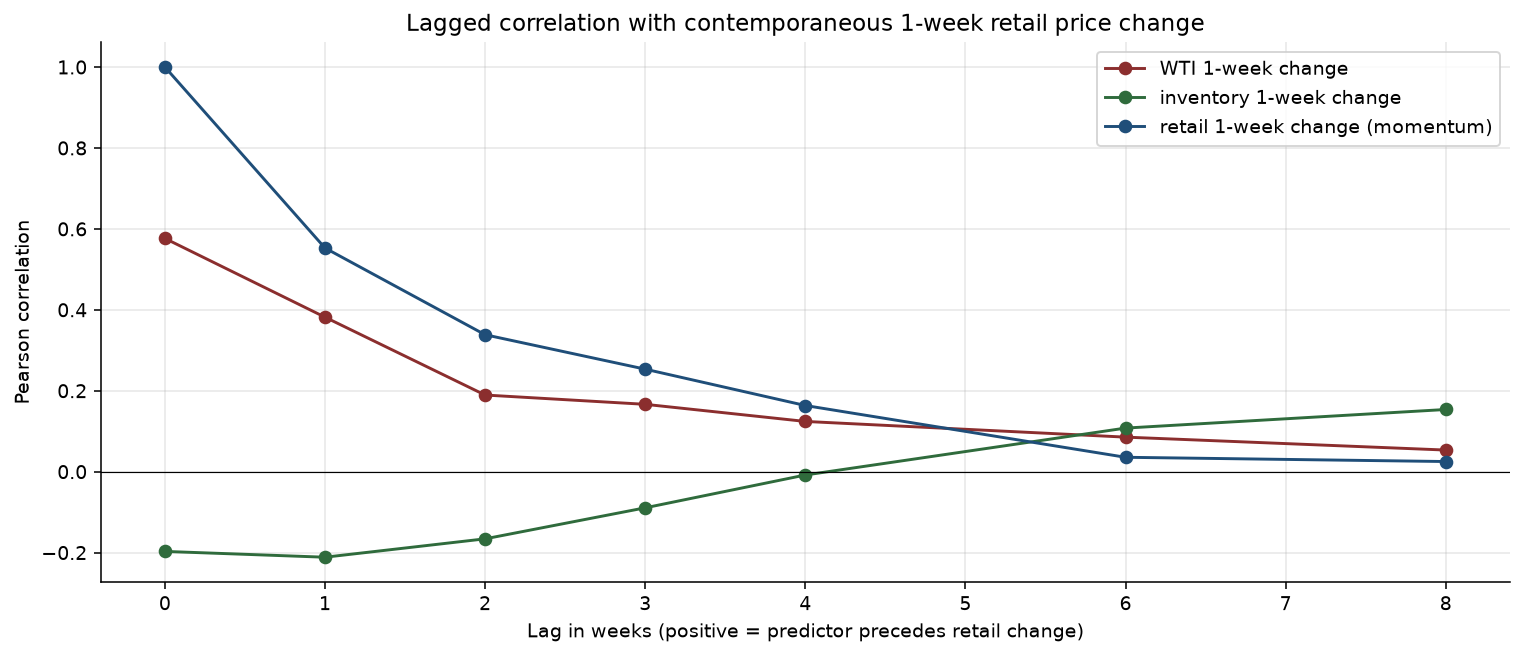

In [10]:
show_figure("lagged_correlations.png")



## 7. Seasonality

Retail *levels* are highest in late spring / early summer and lowest in winter, but that mix of trend and season is misleading. The cleaner seasonal object is the **average 1-week change by month**:

- Prices tend to **rise** January–May (March is the strongest: about +2.9¢/week).
- Prices tend to **fall** June–December, especially October–December (about −1.6¢ to −1.8¢/week).
- November: 70% of weeks are down; March: only 33% are down.

That is a real seasonal drift, but week-to-week shocks from WTI still dominate. Year-over-year percent change is saved on the panel as `retail_yoy_pct` for later residual seasonality checks. We should use **month dummies or a month-of-year mean change**, not raw month-level prices.



In [11]:
monthly = pd.read_csv(PROCESSED / "eda_seasonality_monthly.csv")
monthly



    month  retail_mean  retail_median  retail_1w_mean  retail_1w_pct_negative  stocks_mean    n
0       1       2.1166         2.2290          0.0063                  0.4395  226137.1401  157
1       2       2.1328         2.2400          0.0171                  0.4138  231978.0483  145
2       3       2.2538         2.3180          0.0293                  0.3312  224944.9688  160
3       4       2.3607         2.3840          0.0189                  0.3377  217907.5844  154
4       5       2.4244         2.3690          0.0158                  0.3522  217143.4528  159
5       6       2.4433         2.5240         -0.0071                  0.5871  219286.5742  155
6       7       2.4077         2.4630         -0.0035                  0.5472  217936.1761  159
7       8       2.3509         2.4545         -0.0037                  0.5625  212765.0375  160
8       9       2.3128         2.4370         -0.0063                  0.6129  208941.1548  155
9      10       2.2623         2.2770   

In [12]:
quarterly = pd.read_csv(PROCESSED / "eda_seasonality_quarterly.csv")
quarterly



   quarter  retail_mean  retail_1w_mean  retail_1w_pct_negative    n
0        1       2.1692          0.0177                  0.3939  462
1        2       2.4097          0.0092                  0.4252  468
2        3       2.3575         -0.0045                  0.5738  474
3        4       2.1745         -0.0160                  0.6802  469


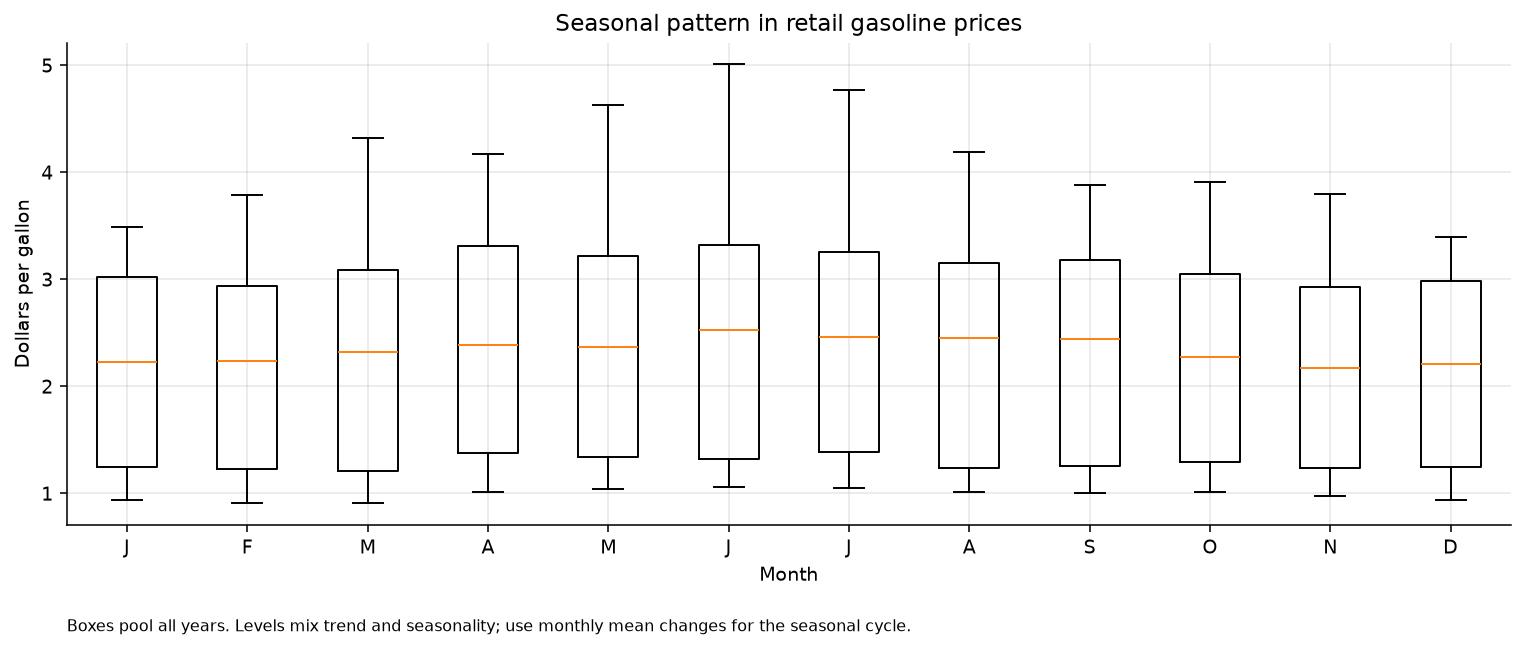

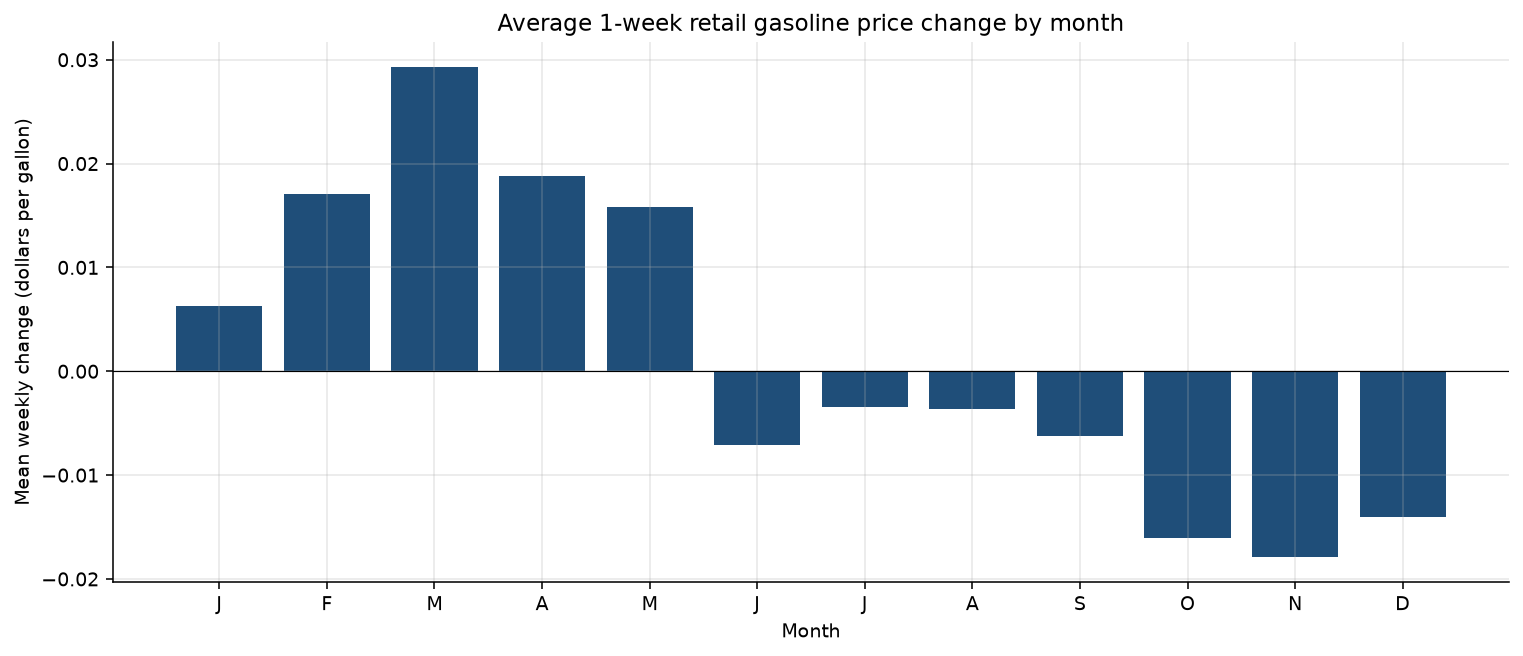

In [13]:
show_figure("seasonal_retail_boxplot.png")
show_figure("seasonal_weekly_change_by_month.png")



## 8. Unusual price movements

We flag the top 1% of absolute 1-week retail percent changes and then **annotate** known historical windows. These events are **not** encoded as model features.

Largest moves cluster in:

- Hurricane Katrina (2005-09-05, +17.6%)
- Russia-Ukraine war (2022-03-07, +13.7%)
- Gulf War restart of the series (1991-01-21, −11.1% after the 1990–91 collection gap)
- 2008 crash (multiple October–November 2008 weeks, −7% to −10%)
- 2017-09-04 (+11.7%), unlabeled here, lines up with Hurricane Harvey
- Several 2026 spikes that moved with WTI the same week (for example 2026-03-09, +16.2% retail with +19.0% WTI)

The tail is real. A model that only fits "normal" 3¢ weeks will fail in crisis weeks. That argues for a **NO CLEAR SIGNAL** bucket when residuals or realized volatility are extreme — not for hard-coding event dummies yet.



In [14]:
unusual = pd.read_csv(PROCESSED / "eda_unusual_movements.csv")
unusual.head(15)



   observation_date  retail_price  retail_chg_1w  retail_pct_1w  wti_price  wti_pct_1w  gasoline_stocks                     historical_event
0        2005-09-05        3.0690         0.4590         0.1759    68.4700      0.0321           190067                    Hurricane Katrina
1        2026-03-09        3.5020         0.4870         0.1615    78.3700      0.1898           249476                                  NaN
2        2022-03-07        4.1020         0.4940         0.1369   106.8000      0.1586           244606       Russia-Ukraine war price spike
3        2017-09-04        2.6790         0.2800         0.1167    46.6800     -0.0210           226738                                  NaN
4        1991-01-21        1.1920        -0.1490        -0.1111    26.8500     -0.1692           216098           Gulf War / Kuwait invasion
5        2008-11-03        2.4000        -0.2560        -0.0964    65.2100     -0.0489           196113  2008 oil spike and financial crisis
6        2008

## 9–10. Is there enough signal to model? Candidate targets

There **is** statistical signal: WTI changes, retail momentum, mild inventory effects, and seasonality all move with future retail prices at rates far above chance.

There is **not** enough in these three weekly series to support a 3-day consumer product. The native decision grain is **one week**.

Average absolute 1-week retail move: **3.3¢**. Only **10%** of weeks does waiting save ≥5¢; **2.7%** save ≥10¢. A classifier that is "right" about direction can still be economically irrelevant.

Simple (non-ML) baselines on 1-week-ahead direction:

- Majority class (price falls): 51.9%
- Sign of this week's WTI change: **62.4%**
- Sign of this week's retail change (momentum): **68.8%**

That is enough to justify a **first statistical model**, with a dead zone for NO CLEAR SIGNAL. It is not enough to justify a high-confidence 72-hour app recommendation.



In [15]:
targets = pd.read_csv(PROCESSED / "eda_target_diagnostics.csv")
targets[
    [
        "target",
        "n",
        "mean_abs_change_usd",
        "share_price_lower",
        "share_save_at_least_5c",
        "share_save_at_least_10c",
        "corr_wti_chg_1w",
        "corr_retail_momentum",
        "sign_acc_wti_chg",
        "sign_acc_momentum",
        "majority_baseline",
    ]
]



                                           target     n  mean_abs_change_usd  share_price_lower  share_save_at_least_5c  share_save_at_least_10c  corr_wti_chg_1w  corr_retail_momentum  sign_acc_wti_chg  sign_acc_momentum  majority_baseline
0         TARGET A: retail change 1 week(s) ahead  1872               0.0329             0.5190                  0.1004                   0.0267           0.3817                0.5527            0.6243             0.6879             0.5190
1         TARGET B: retail change 2 week(s) ahead  1871               0.0592             0.5029                  0.1895                   0.0860           0.3249                0.5062            0.6230             0.6781             0.5029
2         TARGET C: retail change 3 week(s) ahead  1870               0.0822             0.4939                  0.2280                   0.1340           0.3045                0.4720            0.6073             0.6512             0.5061
3  TARGET D: cheaper fill exists within 

# Modeling Implications

## A. Which variables appear predictive?

**Use**
- WTI 1-week *dollar* change, lags 0–2 (lag 0 = Friday before the retail Monday; lag 1 is the first fully forward-looking crude lag).
- Recent retail change (momentum / stickiness), lags 1–2.
- Month-of-year or average weekly seasonal drift.
- Gasoline inventory 1-week change at lags 0–2, as a weak secondary supply feature.

**Do not treat as predictive without transformation**
- Raw retail or WTI *levels* (0.96 correlation is trend).
- Inventory *level* or seasonal deviation (near-zero residual relationship).
- WTI lags beyond ~4 weeks (correlation has mostly died).
- Raw WTI percent changes (unstable when oil prices approach zero).

## B. What time lags appear useful?

Measured, not assumed:

- Strongest WTI association is lag 0 on the as-of panel (already +3 calendar days of crude lead): **r = 0.58**.
- Still useful: **1 week** (r = 0.38) and **2 weeks** (r = 0.19).
- Inventories: **1 week** is the peak (r = −0.21).
- Beyond 4 weeks, keep lags only if a later model proves they survive out-of-sample; the bivariate evidence is weak.

A 6–8 week crude pass-through is **not** what this national weekly panel shows. Pass-through is front-loaded.

## C. What transformations appear appropriate?

- Model **changes**, not levels. First differences in $/gal and $/bbl, or log-differences for WTI after handling the 2020 collapse.
- Prefer dollar changes or rank/robust measures over raw percent changes for crude.
- Add calendar month (or a repeating seasonal mean weekly change).
- Consider a volatility or absolute-change feature so the model can abstain in crisis weeks.
- Do **not** resample weekly series to daily.
- Correct inventory units to thousand barrels (the EIA series description), not million barrels from our metadata.

## D. What information is missing that would likely improve the model?

In priority order for the product, not for a general oil-market model:

1. **Higher-frequency retail prices** (daily city/state pump prices). Weekly EIA cannot support a 3-day WAIT/FILL call.
2. Wholesale / RBOB gasoline, which should sit between WTI and the pump and may tighten the lag.
3. Refinery utilization and gasoline production (supply tightness beyond stocks).
4. Product supplied / demand proxy.
5. Geographic disaggregation (PADDs or metro areas). National average hides local spikes.
6. Publication timestamps, not just observation-week dates, so we never use a number before it was public.

## E. What is the biggest limitation of the current dataset?

**Frequency, not sample size.** We have ~1,870 clean aligned weeks — plenty for a first model — but every observation is weekly, retail and crude are on different weekdays, and the typical move is 3¢. That cannot honestly power a 3-day consumer recommendation. The second limitation is **pass-through compression**: most WTI information is already in the same week as the retail print, so the *remaining* 1-week-ahead edge is real but modest.

## F. What should the target variable be?

| Candidate | Verdict |
| --- | --- |
| A. Retail change 1 week ahead | **Primary statistical target.** Strongest measured associations; matches native frequency. |
| B. 2 weeks ahead | Secondary / robustness label. Slightly weaker WTI correlation (0.32 vs 0.38); larger typical move (5.9¢). |
| C. 3 weeks ahead | Too far for the product; signal keeps decaying. |
| D. Price lower sometime in 1–3 weeks | **Reject as the main target.** Base rate is 62% because the *minimum* of three future prices is biased downward even under a near-random walk. |
| E. Dollars saved by waiting 1 week | **Product-facing recoding of A** (it is A with the sign flipped). Use this for decision metrics, not as a separate label. |

**Recommendation**

Train later models on **TARGET A**: the 1-week-ahead retail price change, in dollars per gallon.

Map to the product with a dead zone, which is how TARGET E becomes an action:

- **FILL UP** if the predicted 1-week change is above a threshold (candidate: +3¢ to +5¢, near the historical mean absolute weekly move).
- **WAIT** if the predicted change is below the negative of that threshold.
- **NO CLEAR SIGNAL** otherwise, and also when volatility is extreme.

Do not use TARGET D. It looks attractive because "waiting 1–3 weeks would have been cheaper 62% of the time," but that is mostly the option value of looking at three future weeks, not a forecastable edge.

A first model is justified. A 3-day mobile recommendation is not justified until we have a higher-frequency retail source.

Saved analysis tables (under `data/processed/`):

- `eda_coverage_summary.csv`
- `eda_missing_observations.csv`
- `eda_alignment_summary.csv`
- `eda_change_stats.csv`
- `eda_correlations.csv`
- `eda_lagged_correlations.csv`
- `eda_seasonality_monthly.csv`
- `eda_seasonality_quarterly.csv`
- `eda_unusual_movements.csv`
- `eda_target_diagnostics.csv`
- `eda_weekly_panel.csv`
- `eda_findings.json`

